# The Dragon Portfolio — a quantitative teardown 🔬
### Core vs full 5-sleeve backtests · HAC & block-bootstrap inference · the 2020/2022 crisis anatomy · the VXX decay diagnostic · the DBMF proxy-quality check · a synthetic crisis-alpha control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![A_cheap_ETF_Dragon%3F: Busted](https://img.shields.io/badge/A_cheap_ETF_Dragon%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Cole's claim — a 5-sleeve mix (equity/bonds/gold/trend/long-vol, published weights 24/18/19/18/21%) survives both inflationary and deflationary regimes — is tested on the only public tape available: liquid ETFs since 2007 (ex-vol) or 2018 (with VXX). No claim is made about the un-testable 100-year secular cycle.

> ⚠️ **Data note.** SPY/TLT/GLD/DBC/VXX/SHY daily auto-adjusted closes (yfinance, cached, fingerprint `3dd12240ccde`); DBMF (2019→) as a side-check only. **Named data quirk:** VXX the product dates to 2009-01-30, but yfinance's own tape starts 2018-01-25 (the 2018 'Series B' relaunch) — the true binding constraint on the full 5-sleeve window. No cross-sectional basket anywhere, so no basket survivorship; VXX's own relaunch history is named instead. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dragon_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.prices_frame(tickers=("SPY", "TLT", "GLD", "DBC", "VXX", "SHY"))
    RET = st.build_returns(PX)
    RF = RET["SHY"]
else:
    PX = RET = RF = None
print("real cache present:", HAVE_REAL, "| tickers:",
      (0 if PX is None else PX.notna().sum().to_dict()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp_prices': '3dd12240ccde', 'core_start': '2007-02-01', 'full_start': '2018-03-01', 'core_n': 4883, 'full_n': 2094, 'dl_cagr': 7.82, 'dl_vol': 9.22, 'dl_sharpe': 0.668, 'dl_dd': -26.4, 'dl_w12': -21.0, 'p6040_core_cagr': 8.3, 'p6040_core_vol': 11.21, 'p6040_core_sharpe': 0.601, 'p6040_core_dd': -31.4, 'p6040_core_w12': -26.2, 'awl_core_cagr': 7.12, 'awl_core_vol': 10.13, 'awl_core_sharpe': 0.551, 'awl_core_dd': -27.9, 'awl_core_w12': -24.8, 'spy_core_cagr': 10.9, 'spy_core_vol': 19.67, 'spy_core_sharpe': 0.519, 'spy_core_dd': -55.2, 'spy_core_w12': -47.4, 'df_cagr': -1.28, 'df_vol': 15.03, 'df_sharpe': -0.148, 'df_dd': -45.0, 'df_w12': -24.7, 'p6040_full_cagr': 8.66, 'p6040_full_vol': 12.15, 'p6040_full_sharpe': 0.596, 'p6040_full_dd': -27.7, 'p6040_full_w12': -25.8, 'awl_full_cagr': 9.64, 'awl_full_vol': 10.14, 'awl_full_sharpe': 0.79, 'awl_full_dd': -18.6, 'awl_full_w12': -13.8, 'spy_full_cagr': 14.72, 'spy_full_vol': 19.18, 'spy_full_sharpe': 0.703, 'spy_full_dd': -33.7, 'spy_full_w12': -19.7, 'c2020_dl': 3.71, 'c2020_6040': 3.67, 'c2020_awl': -2.93, 'c2020_spy': -9.22, 'c2020_df': 33.35, 'y2022_dl': -9.32, 'y2022_6040': -23.32, 'y2022_awl': -8.73, 'y2022_spy': -18.18, 'y2022_df': -10.9, 'vxx_cagr': -40.7, 'vxx_vol': 73.7, 'vxx_dd': -99.5, 'vxx_cum': -98.8, 'vxx_covid': 271.6, 'hac_lite_gap': -0.049, 'hac_lite_t': -0.37, 'hac_lite_n': 233, 'hac_full_gap': -0.801, 'hac_full_t': -1.65, 'hac_full_n': 100, 'boot_lite_pt': 0.067, 'boot_lite_lo': -0.257, 'boot_lite_hi': 0.373, 'boot_lite_win': 67, 'boot_full_pt': -0.745, 'boot_full_lo': -1.987, 'boot_full_hi': 0.357, 'boot_full_win': 9, 'boot_awl_pt': -0.938, 'boot_awl_lo': -1.975, 'boot_awl_hi': 0.086, 'boot_awl_win': 3, 'cost0_cagr': -1.24, 'cost0_sharpe': -0.146, 'cost5_cagr': -1.28, 'cost5_sharpe': -0.148, 'cost10_cagr': -1.31, 'cost10_sharpe': -0.151, 'dbmf_trend_cagr': 9.4, 'dbmf_trend_vol': 15.3, 'dbmf_real_cagr': 9.2, 'dbmf_real_vol': 12.4, 'dbmf_corr': 0.28, 'syn_null_t': -0.22, 'syn_null_sd': 1.2, 'syn_null_fire': 1, 'syn_planted_t': 30.93}


real cache present: True | tickers: {'SPY': 6162, 'TLT': 6018, 'GLD': 5436, 'DBC': 5131, 'VXX': 2118, 'SHY': 6018}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Dragon-lite Sharpe **0.668** vs 60/40 **0.601** (HAC *t* on the monthly gap = **-0.37**, uncertified); Dragon-full Sharpe **-0.148** vs 60/40 **0.596** over 2018-2026 (bootstrap Dragon wins only **9%** of resamples) |
| **Tradability** | `FRAGILE` | Dragon-full CAGR **-1.28%/yr** (negative); VXX standalone **-98.8%** cumulative since 2018 |
| **Cheap ETF Dragon?** | `BUSTED` | wins both crisis episodes (2020 **+33%**, 2022 **-10.9%** vs 60/40 **-23.3%**) but the aggregate Sharpe over the same window is negative |

> 💡 In plain words: the diversification kernel is real; the cheap version of the insurance sleeve isn't paying for itself yet.

## 1 · The claim, steelmanned

Let $w = (0.24, 0.18, 0.19, 0.18, 0.21)$ be Cole's published weights over (SPY, TLT, GLD, TREND, VXX), monthly rebalanced. The claims:

- **H₁ (ex-vol diversification).** The 4-sleeve kernel (equity/bonds/gold/trend, renormalised to 100%) improves risk-adjusted return over 60/40 — higher Sharpe, smaller drawdown — for a small CAGR forfeit.
- **H₂ (crisis convexity).** The long-vol sleeve pays off sharply in a deflationary liquidity crisis (2020) without destroying the aggregate return.
- **H₃ (inflation cushioning).** The mix cushions a stocks-and-bonds-both-down year (2022) better than 60/40.
- **H₄ (cheap tradability).** The whole 5-sleeve mix, built from liquid ETFs at realistic costs, delivers this without a large aggregate return sacrifice.

We find **H₁ directionally supported, not certified** (HAC *t* = -0.37); **H₂ strongly supported** (VXX +272% in the spike window); **H₃ supported** (Dragon-full -10.9% vs 60/40 -23.3% in 2022); **H₄ REJECTED** — Dragon-full's CAGR is negative (-1.28%/yr) over the only testable window.

## 2 · So what? — inference design

Two structurally different questions get two different tests. **Aggregate risk-adjusted comparison** (Dragon vs 60/40 over the whole sample) uses a **Newey-West HAC *t*** on the mean monthly return gap (monthly, matching the rebalance cadence and taming daily autocorrelation) plus a **circular block-bootstrap** CI on the Sharpe *difference* (21-day blocks, 2,000 resamples — preserves volatility clustering an i.i.d. bootstrap would destroy). **Single crisis episodes** (2020, 2022) are reported as exactly that — narrative evidence, n=1 each, no *t*-stat claimed on them (house rule: no conditional claim without uncertainty applies to *aggregate* claims; single historical episodes are named as episodes, not certified as a distribution).

## 3 · How we'd know — the protocol

- **Proxies.** SPY/TLT/GLD/DBC(+12-mo trend overlay)/VXX, monthly rebalance, 5 bps one-way cost per rebalance leg (10 bps sensitivity shown), no shorts/no borrow.
- **Windows.** Core (ex-vol): **2007-02-01 → 2026-06-30**, n=4,883 days. Full (w/ VXX): **2018-03-01 → 2026-06-30**, n=2,094 days — bound by yfinance's VXX tape, not the product's nominal 2009 launch.
- **Execution.** The commodity-trend flag (DBC's trailing 12-month return, known at the prior month's close) decides the following month's position — the study's only forecast, calendar-known, zero look-ahead. Every other sleeve is an exogenous constant weight.
- **Inference.** HAC *t* on the monthly Dragon-minus-60/40 gap; circular block-bootstrap CI on the Sharpe difference.
- **Cross-checks.** VXX standalone decay/spike diagnostic; DBMF (real managed-futures ETF) correlation check on the trend proxy.
- **Control.** Synthetic monthly 5-asset world, planted crisis-alpha knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The core (ex-vol) headline and its inference

Fixed-weight blend, monthly rebalance, HAC *t* on the mean monthly return gap vs 60/40, bootstrap CI on the Sharpe difference.

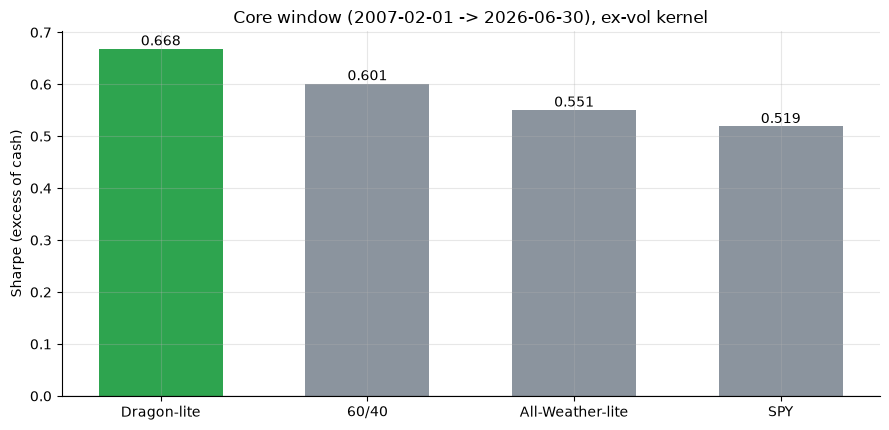

HAC t (Dragon-lite - 60/40, monthly): -0.37  (mean gap -0.049%/mo, n=233)
bootstrap Sharpe diff: +0.067  CI95=[-0.257, +0.373]  Dragon wins 67% of resamples


In [2]:
if HAVE_REAL:
    dlite = st.blended_portfolio(RET, st.DRAGON_LITE, cost_bps=5.0, start=data.CORE_START)
    p6040c = st.blended_portfolio(RET, st.SIXTY_FORTY, cost_bps=5.0, start=data.CORE_START)
    awlc = st.blended_portfolio(RET, st.ALL_WEATHER_LITE, cost_bps=5.0, start=data.CORE_START)
    spyc = st.spy_only(RET, start=data.CORE_START)
    rows = [('Dragon-lite', dlite), ('60/40', p6040c), ('All-Weather-lite', awlc), ('SPY', spyc)]
    stats = {n: st.portfolio_stats(s, rf=RF) for n, s in rows}
    hac = st.hac_diff_monthly(dlite, p6040c)
    boot = st.bootstrap_sharpe_diff(dlite, p6040c, rf=RF, seed=656)
else:
    stats = {'Dragon-lite': {'sharpe': R['dl_sharpe'], 'max_dd': R['dl_dd']/100, 'cagr': R['dl_cagr']/100},
             '60/40': {'sharpe': R['p6040_core_sharpe'], 'max_dd': R['p6040_core_dd']/100, 'cagr': R['p6040_core_cagr']/100},
             'All-Weather-lite': {'sharpe': R['awl_core_sharpe'], 'max_dd': R['awl_core_dd']/100, 'cagr': R['awl_core_cagr']/100},
             'SPY': {'sharpe': R['spy_core_sharpe'], 'max_dd': R['spy_core_dd']/100, 'cagr': R['spy_core_cagr']/100}}
    hac = {'t': R['hac_lite_t'], 'mean_diff_monthly': R['hac_lite_gap']/100, 'n_months': R['hac_lite_n']}
    boot = {'point': R['boot_lite_pt'], 'ci95': (R['boot_lite_lo'], R['boot_lite_hi']), 'frac_a_wins': R['boot_lite_win']/100}
names = list(stats.keys())
sharpes = [stats[n]['sharpe'] for n in names]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [GREEN if n == 'Dragon-lite' else GREY for n in names]
ax.bar(names, sharpes, color=cols, width=.6)
for i,v in enumerate(sharpes): ax.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title(f'Core window ({R["core_start"]} -> {R["asof"]}), ex-vol kernel')
plt.tight_layout(); plt.show()
print(f"HAC t (Dragon-lite - 60/40, monthly): {hac['t']:+.2f}  "
      f"(mean gap {hac['mean_diff_monthly']*100:+.3f}%/mo, n={hac['n_months']})")
print(f"bootstrap Sharpe diff: {boot['point']:+.3f}  "
      f"CI95=[{boot['ci95'][0]:+.3f}, {boot['ci95'][1]:+.3f}]  "
      f"Dragon wins {boot['frac_a_wins']*100:.0f}% of resamples")

> 💡 In plain words: Dragon-lite's Sharpe (0.668) beats 60/40's (0.601) on the chart, but the HAC *t* on the underlying monthly gap is only **-0.37** and the bootstrap CI [-0.257, +0.373] straddles zero — Dragon wins **67%** of resamples, better than a coin flip but nowhere near certified. H₁: directionally real, not statistically proven with 19 years of data.

### 4b · The full 5-sleeve Dragon — where the vol sleeve bites

Same construction, real VXX at 21% weight, window bound by yfinance's VXX tape (2018-03-01 onward).

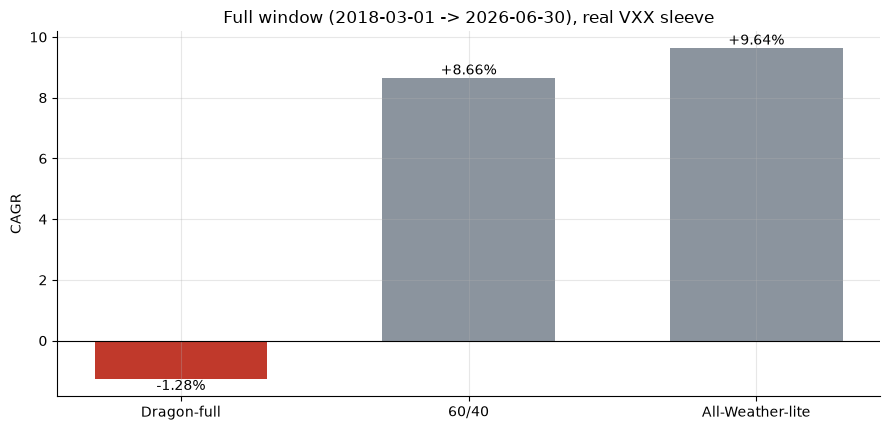

HAC t (Dragon-full - 60/40, monthly): -1.65  (mean gap -0.801%/mo, n=100)
bootstrap Sharpe diff vs 60/40: -0.745  CI95=[-1.987, +0.357]  Dragon wins 9% of resamples
bootstrap Sharpe diff vs All-Weather-lite: -0.938  CI95=[-1.975, +0.086]  Dragon wins 3% of resamples


In [3]:
if HAVE_REAL:
    dfull = st.blended_portfolio(RET, st.DRAGON_FULL, cost_bps=5.0, start=data.FULL_START)
    p6040f = st.blended_portfolio(RET, st.SIXTY_FORTY, cost_bps=5.0, start=data.FULL_START)
    awlf = st.blended_portfolio(RET, st.ALL_WEATHER_LITE, cost_bps=5.0, start=data.FULL_START)
    rows_f = [('Dragon-full', dfull), ('60/40', p6040f), ('All-Weather-lite', awlf)]
    stats_f = {n: st.portfolio_stats(s, rf=RF) for n, s in rows_f}
    hac_f = st.hac_diff_monthly(dfull, p6040f)
    boot_f = st.bootstrap_sharpe_diff(dfull, p6040f, rf=RF, seed=656)
    boot_awl = st.bootstrap_sharpe_diff(dfull, awlf, rf=RF, seed=656)
else:
    stats_f = {'Dragon-full': {'sharpe': R['df_sharpe'], 'cagr': R['df_cagr']/100},
               '60/40': {'sharpe': R['p6040_full_sharpe'], 'cagr': R['p6040_full_cagr']/100},
               'All-Weather-lite': {'sharpe': R['awl_full_sharpe'], 'cagr': R['awl_full_cagr']/100}}
    hac_f = {'t': R['hac_full_t'], 'mean_diff_monthly': R['hac_full_gap']/100, 'n_months': R['hac_full_n']}
    boot_f = {'point': R['boot_full_pt'], 'ci95': (R['boot_full_lo'], R['boot_full_hi']), 'frac_a_wins': R['boot_full_win']/100}
    boot_awl = {'point': R['boot_awl_pt'], 'ci95': (R['boot_awl_lo'], R['boot_awl_hi']), 'frac_a_wins': R['boot_awl_win']/100}
names_f = list(stats_f.keys())
cagrs_f = [stats_f[n]['cagr']*100 for n in names_f]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if n == 'Dragon-full' else GREY for n in names_f]
ax.bar(names_f, cagrs_f, color=cols, width=.6)
for i,v in enumerate(cagrs_f): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('CAGR')
ax.set_title(f'Full window ({R["full_start"]} -> {R["asof"]}), real VXX sleeve')
plt.tight_layout(); plt.show()
print(f"HAC t (Dragon-full - 60/40, monthly): {hac_f['t']:+.2f}  "
      f"(mean gap {hac_f['mean_diff_monthly']*100:+.3f}%/mo, n={hac_f['n_months']})")
print(f"bootstrap Sharpe diff vs 60/40: {boot_f['point']:+.3f}  "
      f"CI95=[{boot_f['ci95'][0]:+.3f}, {boot_f['ci95'][1]:+.3f}]  "
      f"Dragon wins {boot_f['frac_a_wins']*100:.0f}% of resamples")
print(f"bootstrap Sharpe diff vs All-Weather-lite: {boot_awl['point']:+.3f}  "
      f"CI95=[{boot_awl['ci95'][0]:+.3f}, {boot_awl['ci95'][1]:+.3f}]  "
      f"Dragon wins {boot_awl['frac_a_wins']*100:.0f}% of resamples")

> 💡 In plain words: neither comparison formally clears significance — the CIs still straddle zero — but the point estimates lean hard negative (Dragon wins only **9%** of resamples vs 60/40, **3%** vs All-Weather-lite) and the HAC *t* vs 60/40 is **-1.65**, closing in on but not crossing the bar. Honest read: "probably worse on this tape, not certainly" — H₄ (cheap tradability) is rejected on the point estimate even without full certification.

### 4c · The VXX decay diagnostic — why the full sleeve bites

The mechanism, isolated: VXX's own buy-and-hold return.

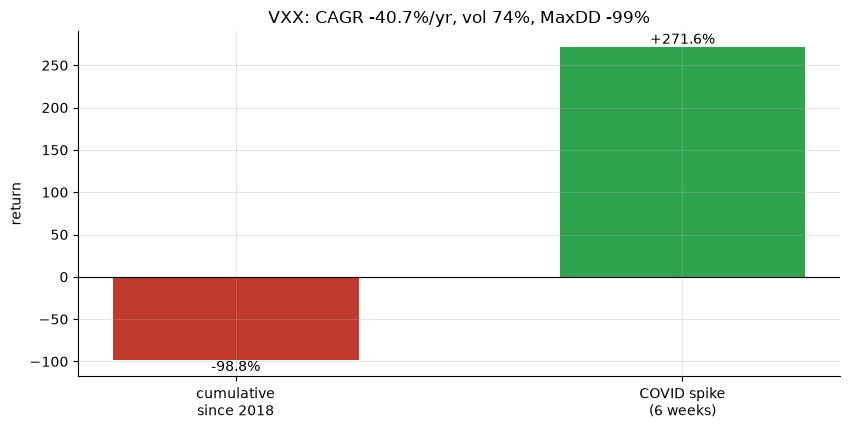

VXX CAGR -40.7%/yr  cumulative -98.8%  COVID spike +271.6%


In [4]:
if HAVE_REAL:
    vxx_ret = RET['VXX'].dropna()
    vxx_s = st.portfolio_stats(vxx_ret)
    cum = float((1.0 + vxx_ret).prod() - 1.0) * 100
    covid = st.window_return(vxx_ret, '2020-02-19', '2020-03-23') * 100
else:
    vxx_s = {'cagr': R['vxx_cagr']/100, 'vol': R['vxx_vol']/100, 'max_dd': R['vxx_dd']/100}
    cum, covid = R['vxx_cum'], R['vxx_covid']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['cumulative\nsince 2018','COVID spike\n(6 weeks)'], [cum, covid],
       color=[RED, GREEN], width=.55)
for i,v in enumerate([cum, covid]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('return')
ax.set_title(f'VXX: CAGR {vxx_s["cagr"]*100:+.1f}%/yr, vol {vxx_s["vol"]*100:.0f}%, '
             f'MaxDD {vxx_s["max_dd"]*100:.0f}%')
plt.tight_layout(); plt.show()
print(f'VXX CAGR {vxx_s["cagr"]*100:+.1f}%/yr  cumulative {cum:+.1f}%  '
      f'COVID spike {covid:+.1f}%')

> 💡 In plain words: an 8.4-year, **-100%**-drawdown asset that pays off **+272%** in six weeks once. At 21% portfolio weight that single payoff is not remotely enough to offset the compounding daily bleed in between. H₂ (crisis convexity) is confirmed as a *mechanism*; H₄ (cheap tradability) fails because the mechanism's cost, paid continuously, currently exceeds its payoff, realized rarely.

### 4d · The DBMF side-check — is the trend proxy even fair?

Real managed-futures ETF (DBMF, 2019→) vs our single-index DBC trend overlay, over their overlap.

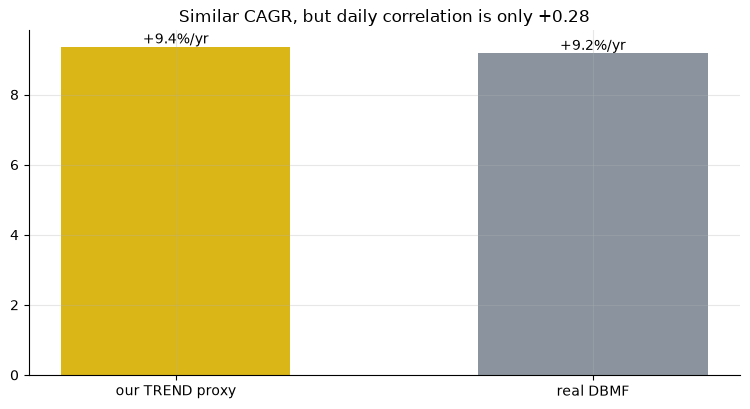

correlation: +0.28  |  TREND proxy +9.4%/yr  vs  DBMF +9.2%/yr


In [5]:
if HAVE_REAL and 'DBMF' in data.load_real():
    real = data.load_real()
    dbmf_ret = real['DBMF'].pct_change().dropna()
    trend_ret = RET['TREND'].dropna()
    common = dbmf_ret.index.intersection(trend_ret.index)
    corr = float(np.corrcoef(dbmf_ret.loc[common], trend_ret.loc[common])[0, 1])
    t_cagr = st.portfolio_stats(trend_ret.loc[common])['cagr'] * 100
    d_cagr = st.portfolio_stats(dbmf_ret.loc[common])['cagr'] * 100
else:
    corr, t_cagr, d_cagr = R['dbmf_corr'], R['dbmf_trend_cagr'], R['dbmf_real_cagr']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['our TREND proxy','real DBMF'], [t_cagr, d_cagr], color=[AMBER, GREY], width=.55)
for i,v in enumerate([t_cagr, d_cagr]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom')
ax.set_title(f'Similar CAGR, but daily correlation is only {corr:+.2f}')
plt.tight_layout(); plt.show()
print(f'correlation: {corr:+.2f}  |  TREND proxy {t_cagr:+.1f}%/yr  vs  DBMF {d_cagr:+.1f}%/yr')

> 💡 In plain words: **+0.28** correlation despite similar headline CAGR — a single long/flat overlay on one commodity index is a materially cruder proxy for Cole's diversified multi-market trend sleeve than the ticker choice alone would suggest. Named, not hidden.

### 4e · Synthetic crisis-alpha control — we know the truth here

Deterministic monthly 5-asset world; the test isolates the mechanism directly — does the Dragon-weighted TREND+VOL sub-sleeve pay off MORE in crisis months than normal months? (Not "Dragon vs 60/40" — a lower equity weight alone would win any stock crash with zero genuine crisis alpha, which would make a naive null fire on a pure beta artefact.) Null checked over **20 seeds**.

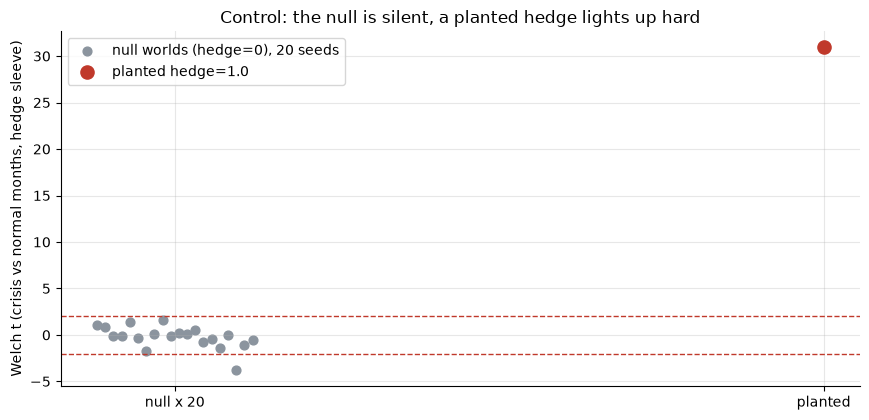

null: mean t = -0.22 (sd 1.20), |t|>=2 in 1/20 seeds  |  planted t = +30.93


In [6]:
null_ts = []
for s_ in range(20):
    frame, truth = data.synthetic_world(hedge_strength=0.0, seed=656 + s_)
    null_ts.append(st.synthetic_crisis_test(frame, truth)['welch_t'])
null_ts = np.asarray(null_ts)
frame, truth = data.synthetic_world(hedge_strength=1.0, seed=656)
planted_t = st.synthetic_crisis_test(frame, truth)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (hedge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted hedge=1.0')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (crisis vs normal months, hedge sleeve)')
ax.set_title('Control: the null is silent, a planted hedge lights up hard')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires in **1/20** seeds — about the 5% nominal false-positive rate of a two-sided \|t\|≥2 test, not a systematic bias — and a planted crisis-alpha effect reads t = **30.9**. The machinery is unbiased; the real-tape result above is the genuine article, not an artefact of the test. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — ex-vol, Dragon-lite's Sharpe advantage over 60/40 (0.668 vs 0.601) is real-looking but uncertified (HAC *t* = -0.37, bootstrap CI crosses zero). With the real VXX sleeve, the aggregate Sharpe over the only testable window (2018-2026) turns negative (-0.148), even as the same sleeve delivers +33% in the 2020 crash and cushions 2022 (-10.9% vs -23.3%). Genuinely split by regime and by leg — the textbook use of the `MIXED` stamp.
- **Tradability `FRAGILE`** — cheap, liquid ETFs, negligible cost drag (±0.03pp/yr from 0→10 bps), but the published 5-sleeve allocation lost money outright (-1.28%/yr) over 8+ years; the insurance premium (VXX -98.8% cumulative) has not yet been repaid by the payoff it exists for.
- **"A cheap ETF Dragon just works?" `BUSTED`** — the diversification mechanism is genuine; the *cheap* implementation of the long-vol sleeve is the part the myth gets wrong.

## 6 · Going further

- **The obvious next step is options, not an ETN.** A dynamically-sized OTM SPX put ladder (à la Spitznagel's *Safe Haven*) would isolate convexity without paying VXX's structural roll cost every month it isn't paid off — the natural sequel study.
- **A longer synthetic secular-cycle test** (replicated bond/gold/commodity indices reaching further back, in the spirit of Cole's own paper) would let the desk test the 1970s-style inflation decade this real tape simply doesn't contain.
- **Dedup map:** [68-all-weather](../../68-all-weather/) (risk parity, no vol sleeve), [144-permanent-portfolio](../../144-permanent-portfolio/) (no trend or vol), [617-crash-insurance-cost](../../617-crash-insurance-cost/) (standalone tail-hedge cost), [655-ivy-portfolio](../../655-ivy-portfolio/) (trend-times everything, no vol).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*